# 3 · Tidal tensor, eigenvalues and the cosmic web

The tidal tensor $T_{ij} = \partial_i\partial_j\phi$ with $\nabla^2\phi = \delta$ is a symmetric `TensorField`.
Its ordered eigenvalues $\lambda_1 \ge \lambda_2 \ge \lambda_3$ classify every point as void, sheet,
filament or knot (T-web), and in the Zel'dovich approximation they predict where structures collapse.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from cobox import Box, GRFSampler, IsoModeMask, Particles, Window, ScalarField, stats
from colcdm import LPT, LinearMatterPowSpec, Cosmology

N, L = 64, 250.0                     # 64^3 cells, 250 Mpc/h
box = Box(N, L, 3)
cosmo = Cosmology.from_preset("planck18")
pk = LinearMatterPowSpec(transfer_kind="symbolic_pofk", growth_kind="symbolic_pofk", cosmology=cosmo)
bins = stats.KBins.log(box, 20)
k_th = jnp.logspace(-2.2, 0.1, 200)

/home/prosello/Documents/phd/code/cobox-repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
R_s = 4.0                                                  # smoothing scale, Mpc/h
smooth = Window("gaussian", 2 * R_s, normalized=True)
delta0 = GRFSampler(kind="real").sample_from_seed(0, box, pk)
d_s = delta0.convolve(smooth)

T = d_s.inv_laplacian().hessian()                          # TensorField, symmetric, 6 components
l1, l2, l3 = T.eigenvalues()                               # real-space ScalarFields
print(T.symmetry, T.shape)
print("trace(T) == delta:", float(jnp.abs(T.trace().ifft().data - d_s.ifft().data).max()))

symmetric (6, 64, 64, 33)
trace(T) == delta: 0.002007722854614258


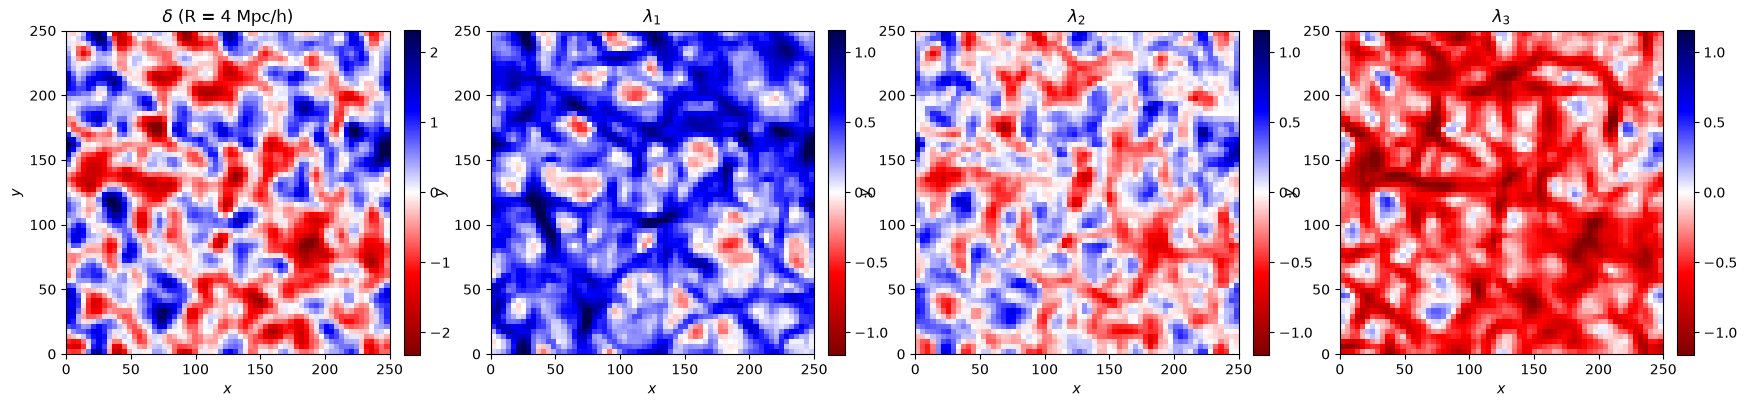

In [3]:
fig, axs = plt.subplots(1, 4, figsize=(21, 4.6))
lim = float(3 * jnp.std(d_s.ifft().data))
d_s.paint(ax=axs[0], cmap="seismic_r", vmin=-lim, vmax=lim, title=f"$\\delta$ (R = {R_s:g} Mpc/h)")
for ax, lam, name in zip(axs[1:], (l1, l2, l3), ("\\lambda_1", "\\lambda_2", "\\lambda_3")):
    lam.paint(ax=ax, cmap="seismic_r", vmin=-lim / 2, vmax=lim / 2, title=f"${name}$")

## Invariants

$I_1 = \mathrm{tr}\,T = \delta$, $I_2$ (sum of principal minors) and $I_3 = \det T$ — the same polynomial
invariants that source 2LPT and 3LPT.

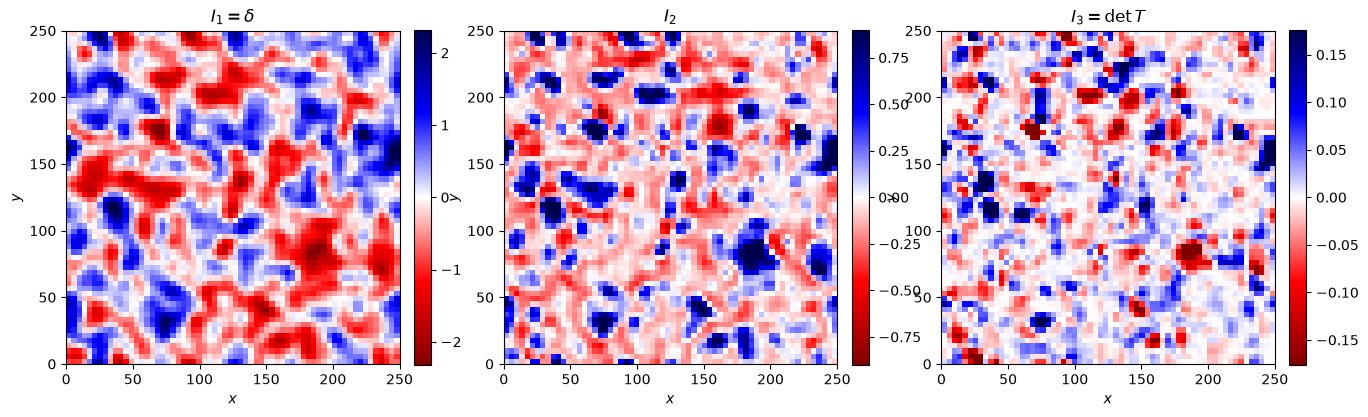

In [4]:
I1, I2, I3 = T.trace(), T.second_invariant(), T.det()
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, f, name in zip(axs, (I1, I2, I3), ("I_1 = \\delta", "I_2", "I_3 = \\det T")):
    s = float(3 * jnp.std(f.ifft().data))
    f.paint(ax=ax, cmap="seismic_r", vmin=-s, vmax=s, title=f"${name}$")

## T-web classification

Count eigenvalues above a threshold $\lambda_{\rm th}$: 0 → void, 1 → sheet, 2 → filament, 3 → knot.
For a Gaussian field with $\lambda_{\rm th} = 0$ the volume fractions are known analytically
(Doroshkevich 1970): 8 %, 42 %, 42 %, 8 %.

{'void': np.float64(0.081), 'sheet': np.float64(0.418), 'filament': np.float64(0.421), 'knot': np.float64(0.08)}


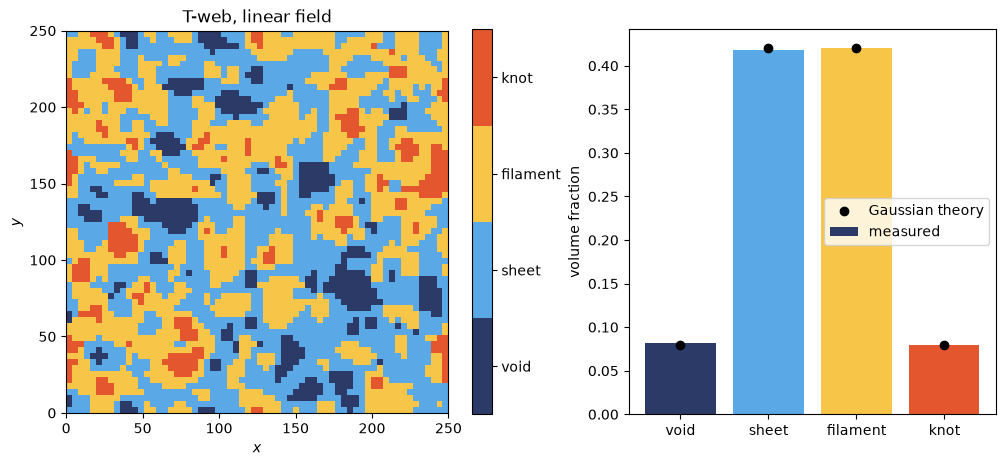

In [5]:
from matplotlib.colors import ListedColormap

web_names = ["void", "sheet", "filament", "knot"]
web_cmap = ListedColormap(["#2b3a67", "#5aa9e6", "#f7c548", "#e4572e"])

def tweb(lams, lam_th=0.0):
    return sum((lam.ifft().data > lam_th).astype(int) for lam in lams)

web = tweb((l1, l2, l3))
fractions = [float((web == i).mean()) for i in range(4)]

fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.3, 1]})
im = axs[0].imshow(np.asarray(web[:, :, N // 2]).T, origin="lower", extent=(0, L, 0, L),
                   cmap=web_cmap, vmin=-0.5, vmax=3.5)
cb = fig.colorbar(im, ax=axs[0], ticks=range(4))
cb.ax.set_yticklabels(web_names)
axs[0].set(title="T-web, linear field", xlabel="$x$", ylabel="$y$")
axs[1].bar(web_names, fractions, color=web_cmap.colors, label="measured")
axs[1].scatter(web_names, [0.08, 0.42, 0.42, 0.08], color="k", zorder=3, label="Gaussian theory")
axs[1].set(ylabel="volume fraction")
axs[1].legend()
print(dict(zip(web_names, np.round(fractions, 3))))

## Eigenvalue PDFs

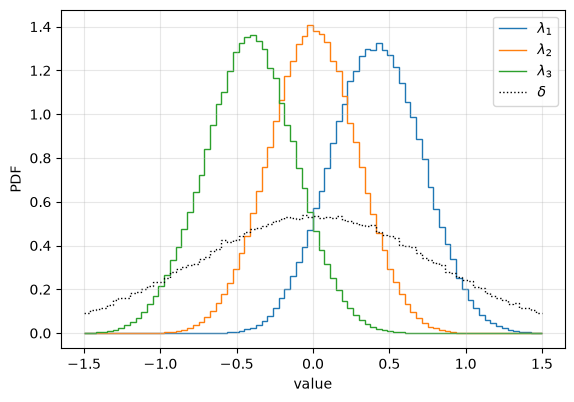

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.4))
for lam, name in zip((l1, l2, l3), ("\\lambda_1", "\\lambda_2", "\\lambda_3")):
    stats.pdf(lam, n_bins=80, range=(-1.5, 1.5), density=True).plot(ax=ax, label=f"${name}$")
stats.pdf(d_s, n_bins=80, range=(-1.5, 1.5), density=True).plot(ax=ax, color="k", ls=":", label="$\\delta$")
ax.set(xlabel="value")
ax.legend();

## Zel'dovich collapse from the eigenvalues

In 1LPT the Jacobian of $\mathbf{x} = \mathbf{q} + \boldsymbol\Psi$ is $I - D\,T$, so
$1 + \delta_{\rm ZA} = 1/\left|(1 - D\lambda_1)(1 - D\lambda_2)(1 - D\lambda_3)\right|$: the first
eigenvalue reaching $1/D$ marks pancake (shell-crossing) formation. Compare to actually moving particles.

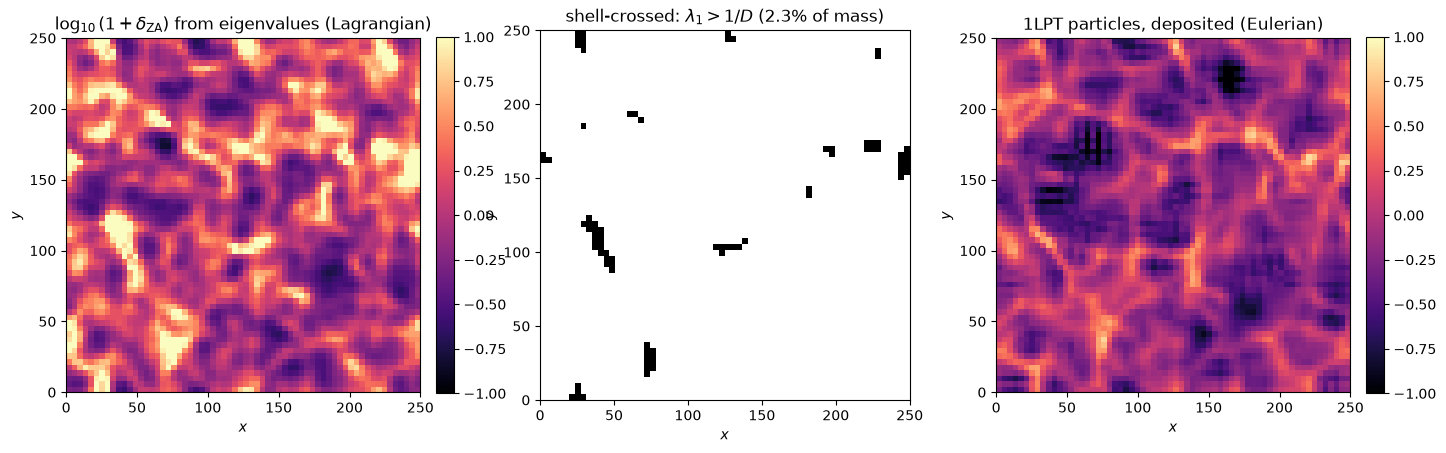

In [7]:
D0 = 1.0                                                     # a = 1: the linear field is already at D(1)
jac = [(1.0 - D0 * lam.ifft().data) for lam in (l1, l2, l3)]
rho_za = 1.0 / jnp.abs(jac[0] * jac[1] * jac[2])
crossed = jac[0] < 0

psi = LPT(1).get_psi(d_s, 1.0, cosmo)
rho_part = Particles(box).displace_from_vector_field(psi, interpolation=None).deposit(N, bspline_order=2)
rho_part = rho_part / float(rho_part.data.mean())

fig, axs = plt.subplots(1, 3, figsize=(17, 4.8))
ScalarField(rho_za, box).paint(ax=axs[0], cmap="magma", log_data=True, vmin=-1, vmax=1,
                               title="$\\log_{10}(1+\\delta_{\\rm ZA})$ from eigenvalues (Lagrangian)")
ScalarField(crossed.astype(float), box).paint(ax=axs[1], cmap="Greys", colorbar=False,
                                              title=f"shell-crossed: $\\lambda_1 > 1/D$ ({float(crossed.mean()):.1%} of mass)")
rho_part.paint(ax=axs[2], cmap="magma", log_data=True, vmin=-1, vmax=1,
               title="1LPT particles, deposited (Eulerian)");

## The web after gravitational evolution

The same classification on the 2LPT-evolved density: filaments and knots grow in mass, voids expand in volume.

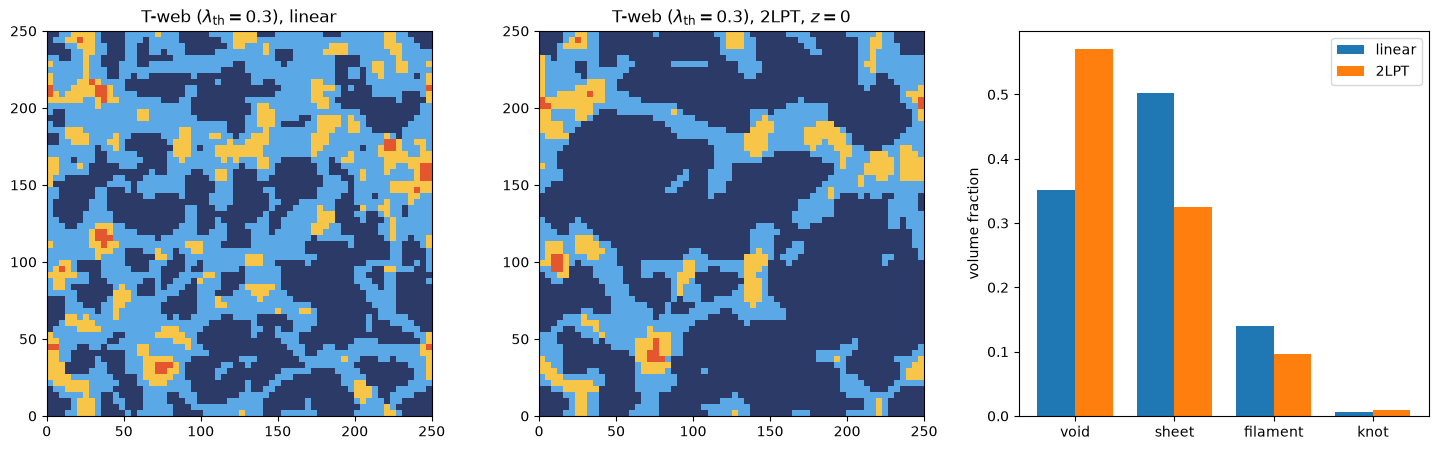

In [8]:
psi2 = LPT(2).get_psi(delta0, 1.0, cosmo)
rho2 = Particles(box).displace_from_vector_field(psi2, interpolation=None).deposit(N, bspline_order=3, return_contrast=True)
T2 = rho2.convolve(smooth).inv_laplacian().hessian()
web2 = tweb(T2.eigenvalues(), lam_th=0.3)
web_lin = tweb((l1, l2, l3), lam_th=0.3)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, w, title in ((axs[0], web_lin, "linear"), (axs[1], web2, "2LPT, $z=0$")):
    im = ax.imshow(np.asarray(w[:, :, N // 2]).T, origin="lower", extent=(0, L, 0, L),
                   cmap=web_cmap, vmin=-0.5, vmax=3.5)
    ax.set(title=f"T-web ($\\lambda_{{\\rm th}} = 0.3$), {title}")
width = 0.38
x = np.arange(4)
axs[2].bar(x - width / 2, [float((web_lin == i).mean()) for i in range(4)], width, label="linear")
axs[2].bar(x + width / 2, [float((web2 == i).mean()) for i in range(4)], width, label="2LPT")
axs[2].set_xticks(x, web_names)
axs[2].set(ylabel="volume fraction")
axs[2].legend();